<a href="https://colab.research.google.com/github/Yanina2105/MD-Lab12_FT/blob/develop/SEMANA_12_Distribuciones_de_probabilidad_a_Priori_y_Posteriori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 12: DISTRIBUCIONES DE PROBABILIDAD A PRIORI Y POSTERIORI**

Con la información tomada del siguiente artículo sobre niveles de obesidad
https://www.sciencedirect.com/science/article/pii/S2352340919306985, en la cual se quiere
predecir estos para una persona y que contiene tres variables numéricas (‘Age’, ‘Height’ y
‘Weight’) siendo el resto categóricas, haga lo siguiente:

## **a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes, tratamiento de outliers a nivel univariado y multivariado, y balanceo de clases.**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('/content/sample_data/obesidad.csv')
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,21,1.71,131.4,yes,yes,3,3,Sometimes,no,2,no,2,1,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,22,1.75,133.7,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,23,1.75,133.7,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24,1.74,133.3,yes,yes,3,3,Sometimes,no,3,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III


In [8]:
df.dtypes

,0
Gender,object
Age,int64
Height,float64
Weight,float64
family_history_with_overweight,object
FAVC,object
FCVC,int64
NCP,int64
CAEC,object
SMOKE,object


In [9]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701620,86.585978,2.423496,2.687826,2.014685,1.006632,0.664614
std,6.357078,0.093368,26.191165,0.583905,0.809680,0.688616,0.895462,0.674009
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.630000,65.450000,2.000000,3.000000,2.000000,0.000000,0.000000
50%,23.000000,1.700000,83.000000,2.000000,3.000000,2.000000,1.000000,1.000000
75%,26.000000,1.770000,107.450000,3.000000,3.000000,2.000000,2.000000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [10]:
# Valores faltantes
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


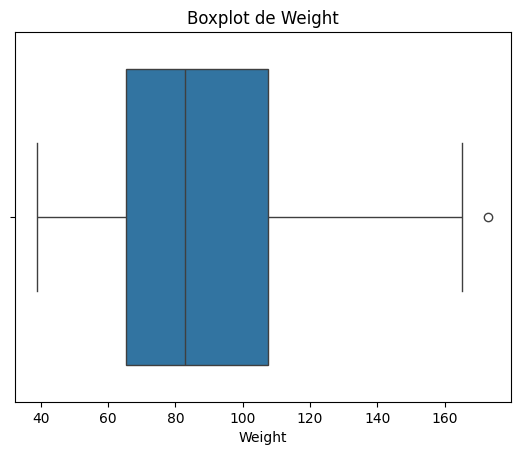

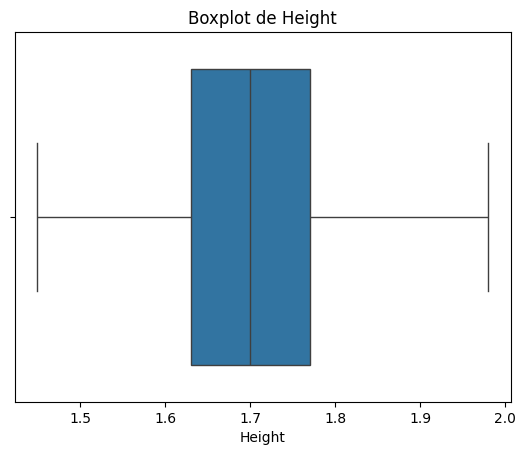

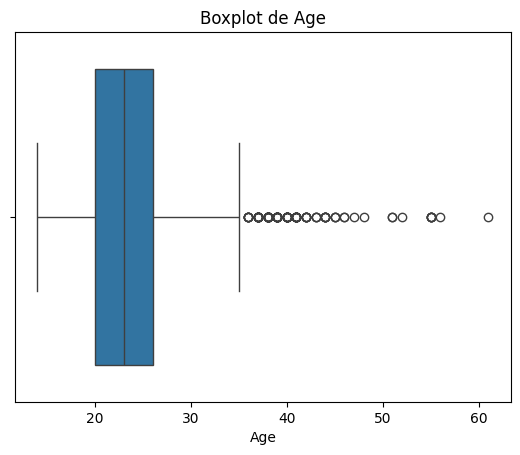

In [17]:
for col in ['Weight', 'Height', 'Age']:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [18]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Aplicar a cada variable
df = remove_outliers_iqr(df, 'Weight')
df = remove_outliers_iqr(df, 'Height')
df = remove_outliers_iqr(df, 'Age')


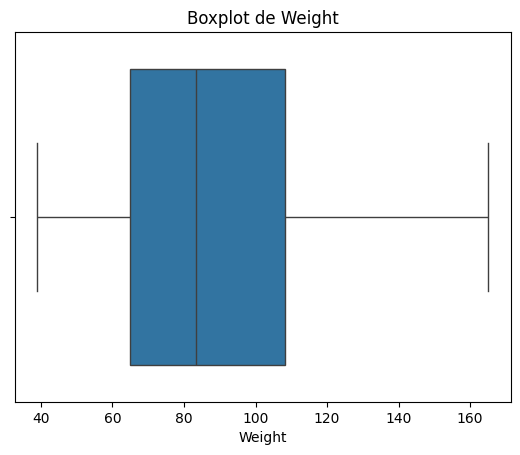

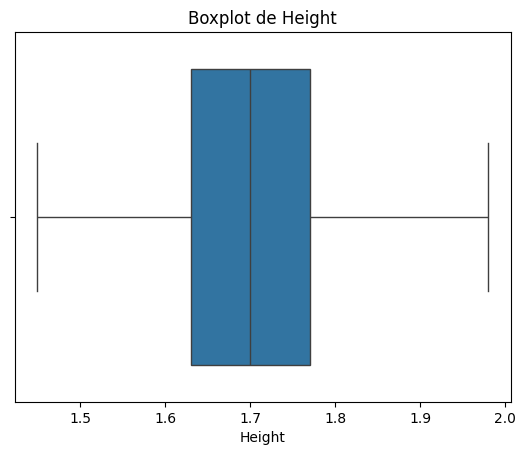

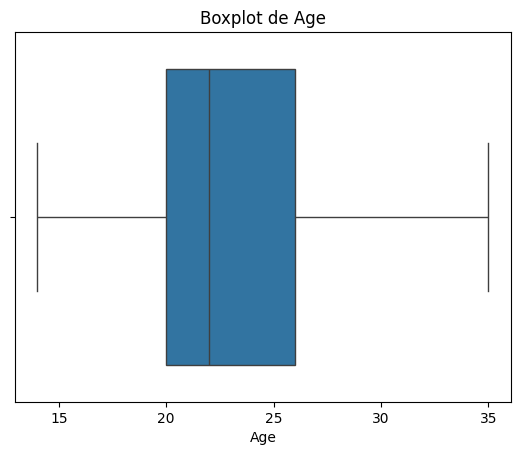

In [20]:
for col in ['Weight', 'Height', 'Age']:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [21]:
from imblearn.over_sampling import SMOTE

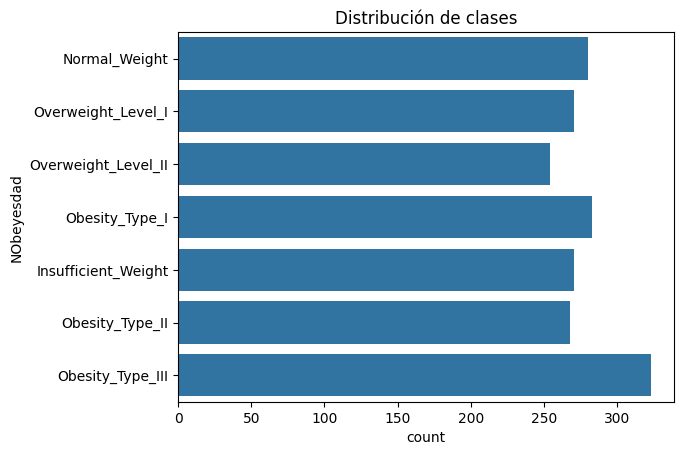

In [22]:
# Visualización de la variable target
sns.countplot(y='NObeyesdad', data=df)
plt.title("Distribución de clases")
plt.show()

# Separar X y y
X = df.drop(columns=["NObeyesdad"])
y = df["NObeyesdad"]

# Convertir categóricas a numéricas temporalmente para usar SMOTE
X_encoded = pd.get_dummies(X, drop_first=True)

# Balanceo con SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_encoded, y)


## **b. Convierta las variables categóricas a dummies por medio de la función ‘OneHotEncoder’ de la librería ‘category_encoders’ la cual debe ser previamente instalada mediante la sentencia ‘!pip install category-encoders’.**

In [25]:
!pip install category-encoders
import category_encoders as ce

encoder = ce.OneHotEncoder(use_cat_names=True)
X_encoded = encoder.fit_transform(X)


## **c. Separe los datos en entrenamiento (80%) y prueba (20%), realice un Naive Bayes mediante la función ‘GaussianNB’ y ‘MultinomialNB’. Compare los accuracy para los resultados obtenidos y diga con cuál de ellos se obtuvo un mejor desempeño.**

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [30]:
# GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

In [57]:
pd.crosstab(y_test, y_pred_gnb, rownames=['Real'], colnames=['Predicción'])

Predicción,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Real,,,,,,,
Insufficient_Weight,46,1,0,12,0,1,0
Normal_Weight,24,12,2,3,0,2,5
Obesity_Type_I,1,2,23,29,2,1,4
Obesity_Type_II,0,1,1,62,0,0,3
Obesity_Type_III,0,0,0,0,56,0,0
Overweight_Level_I,15,3,5,14,0,10,4
Overweight_Level_II,6,1,5,17,0,1,16


In [58]:
accuracy = accuracy_score(y_test, y_pred_gnb)
print("Accuracy =", round(accuracy, 2))

precision = precision_score(y_test, y_pred_gnb, average='weighted')
print("Precisión =", round(precision, 2))

recall = recall_score(y_test, y_pred_gnb, average='weighted')
print("Recall =", round(recall, 2))

f1 = f1_score(y_test, y_pred_gnb, average='weighted')
print("F1-score =", round(f1, 2))

Accuracy = 0.58
Precisión = 0.61
Recall = 0.58
F1-score = 0.54


In [31]:
# MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

In [48]:
pd.crosstab(y_test, y_pred_mnb, rownames=['Real'], colnames=['Predicción'])

Predicción,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Real,,,,,,,
Insufficient_Weight,45,4,0,0,0,2,9
Normal_Weight,16,22,0,0,0,5,5
Obesity_Type_I,0,1,30,14,10,3,4
Obesity_Type_II,0,0,10,54,0,1,2
Obesity_Type_III,0,0,0,0,56,0,0
Overweight_Level_I,4,6,4,7,0,23,7
Overweight_Level_II,0,4,7,8,0,4,23


In [56]:
accuracy = accuracy_score(y_test, y_pred_mnb)
print("Accuracy =", round(accuracy, 2))

precision = precision_score(y_test, y_pred_mnb, average='weighted')
print("Precisión =", round(precision, 2))

recall = recall_score(y_test, y_pred_mnb, average='weighted')
print("Recall =", round(recall, 2))

f1 = f1_score(y_test, y_pred_mnb, average='weighted')
print("F1-score =", round(f1, 2))



Accuracy = 0.65
Precisión = 0.64
Recall = 0.65
F1-score = 0.64


**Conclusión:** El mejor modelo es MultinomialNB ya que es el que tiene mayor accuracy y mejor equilibrio entre precision, recall y f1-score.